In [1]:
import numpy as np
import matplotlib
# matplotlib.use("Agg")   # backend non interactif
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.signal import butter, filtfilt,freqs

import scipy.signal as signal

In [2]:
10 * np.log10(0.041)

-13.872161432802645

/usr/lib/python3/dist-packages/matplotlib/cbook/__init__.py:1369: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


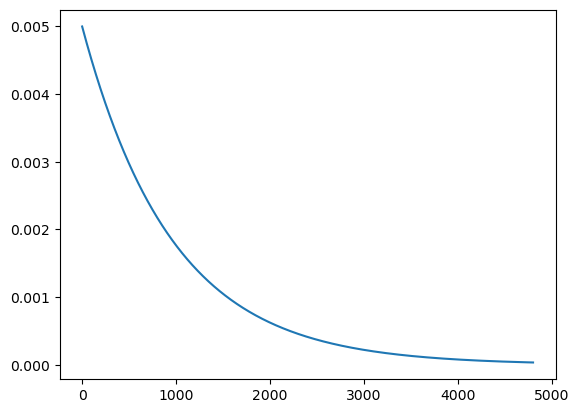

In [3]:
rate = 32e6
pulse_duration = 150e-6
pulse_len = int(pulse_duration * rate)
tp = np.arange(pulse_len) / rate
tau = 30e-6
plt.plot(0.005* np.exp(-tp / tau) * np.exp(1j * 2 * np.pi * tp))

In [3]:
fs = 1e6
T = 1.0

N = int(fs * T)

In [4]:
f_1 = 1e3

phi_1 = np.pi/4

t_1 = np.arange(0, 1, 1/fs)

signal_1 = np.sin(2*np.pi*f_1*t_1 + phi_1)

In [5]:
signal_1

array([0.70710678, 0.71153568, 0.71593648, ..., 0.69365331, 0.69816542,
       0.70264997])

Text(0, 0.5, 'Time s')

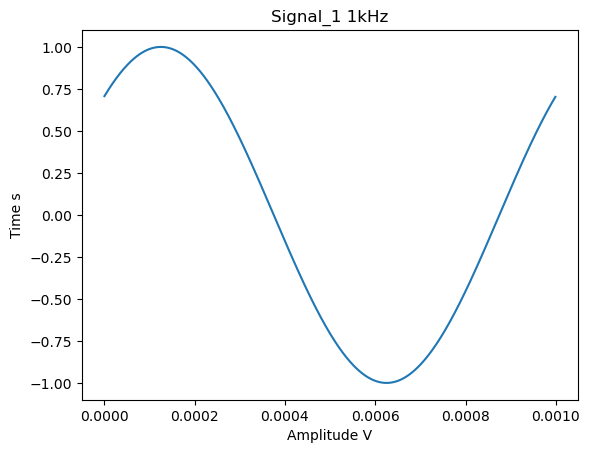

In [6]:
plt.figure()
plt.plot(t_1[0:1000], signal_1[0:1000])
plt.title("Signal_1 1kHz")
plt.xlabel("Amplitude V")
plt.ylabel("Time s")

In [7]:
f_2 = 7e3
phi_2 = np.pi/3
t_2 = np.arange(0, 1, 1/fs)

signal_2 = np.cos(2*np.pi*f_2*t_2 + phi_2)

Text(0, 0.5, 'Time s')

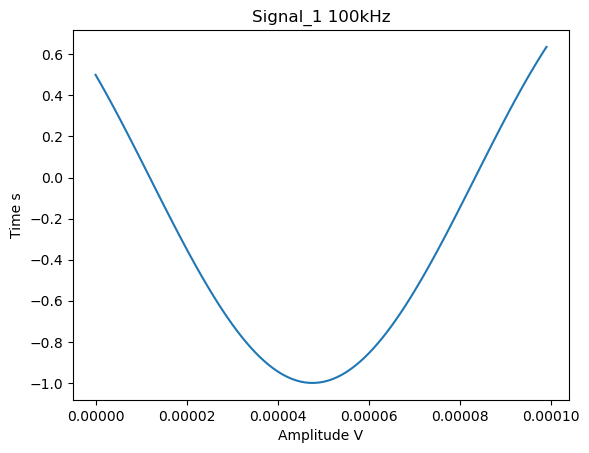

In [8]:
plt.figure()
plt.plot(t_2[0:100], signal_2[0:100])
plt.title("Signal_1 100kHz")
plt.xlabel("Amplitude V")
plt.ylabel("Time s")

In [9]:
signal_1.shape, signal_2.shape

((1000000,), (1000000,))

In [10]:
f_3 = 5e3
phi_3 = np.pi/2
t_3 = np.arange(0, 1, 1/fs)

signal_3 = np.cos(2*np.pi*f_3*t_3 + phi_3)

Text(0, 0.5, 'Time s')

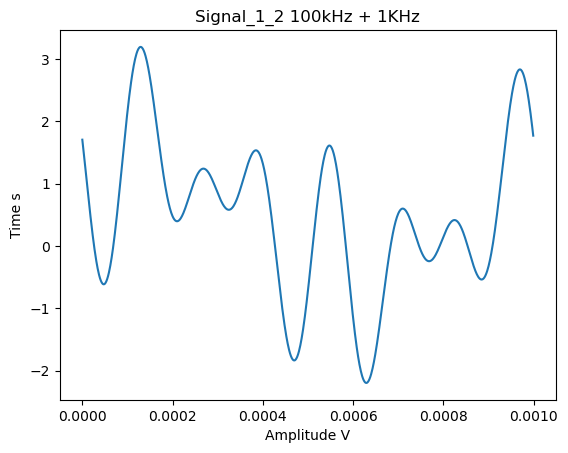

In [22]:
dc_offset = 0.5
signal_1_2_3 = signal_1_2_3 + dc_offset
noise = 1000*np.random.randn(len(signal_1_2_3)) *0

signal_1_2_3 = signal_1_2_3 + noise

plt.figure()
plt.plot(t_1[0:1000], signal_1_2_3[0:1000])
plt.title("Signal_1_2 100kHz + 1KHz")
plt.xlabel("Amplitude V")
plt.ylabel("Time s")

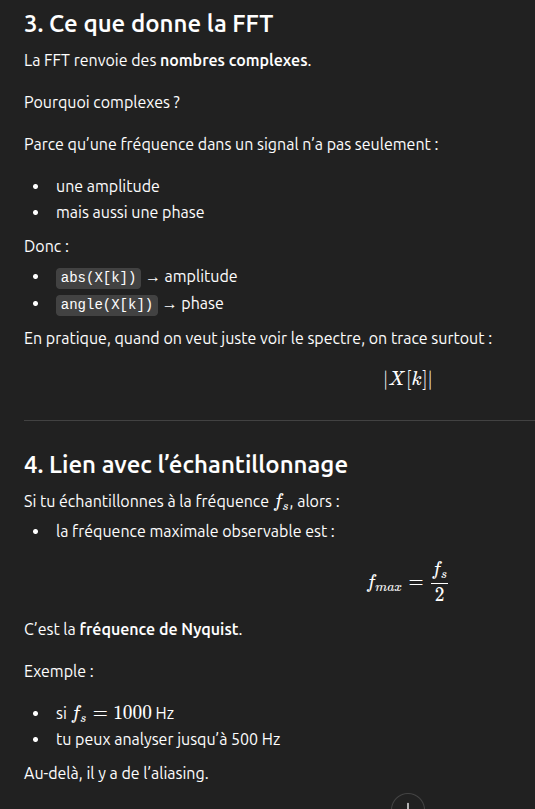
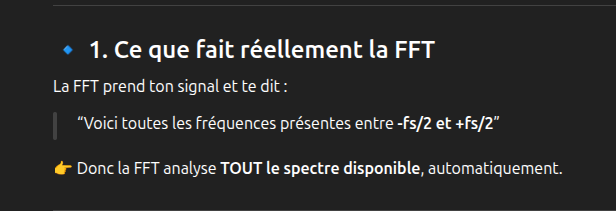
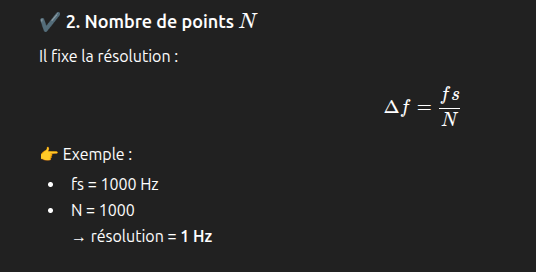

In [23]:
X = np.fft.fft(signal_1_2_3)

freq = np.fft.fftfreq(N, d=1/fs)

Ampl = np.abs(X)

phase = np.angle(X)

freq.shape, Ampl.shape, phase.shape

((1000000,), (1000000,), (1000000,))

In [24]:
(2e9 - 100e6 - 38e6)/(38e6)

49.0

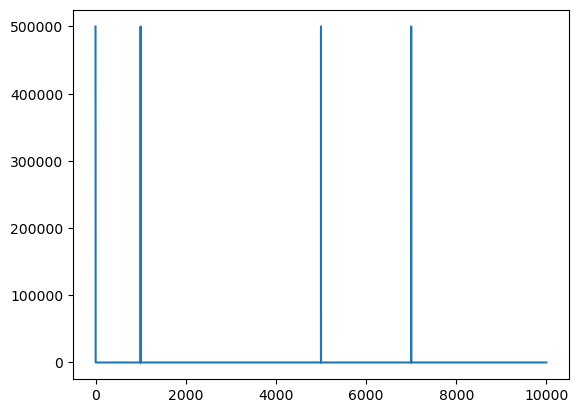

Pic à 1000.000 Hz
Pic à 5000.000 Hz
Pic à 7000.000 Hz
Pic à -7000.000 Hz
Pic à -5000.000 Hz
Pic à -1000.000 Hz


In [25]:
plt.figure()
alpha = int(len(freq)/100)
plt.plot(freq[:alpha], Ampl[:alpha])
# plt.plot(freqs[:], phase[:])

peaks, properties = find_peaks(Ampl, height=10)
# plt.plot(freqs[peaks], Ampl[peaks], "rx") 
plt.show()
for p in peaks:
    print(f"Pic à {freq[p]/1:.3f} Hz")
# plt.xlim(-50000, 50000)
# plt.ylim(0, 200)

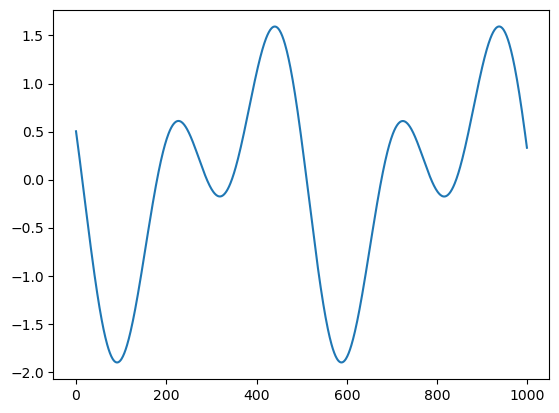

In [41]:
X_filtred = X[np.abs(freq) > 3000]
signal_filtered_freq_domain = np.real(np.fft.ifft(X_filtred))

plt.figure()
plt.plot(signal_filtered_freq_domain[:1000])
plt.show()

In [42]:
X_pf = np.fft.fft(signal_filtered_freq_domain)

freq_pf = np.fft.fftfreq(N, d=1/fs)

Ampl_pf = np.abs(X_pf)


freq_pf.shape, Ampl_pf.shape

((1000000,), (993999,))

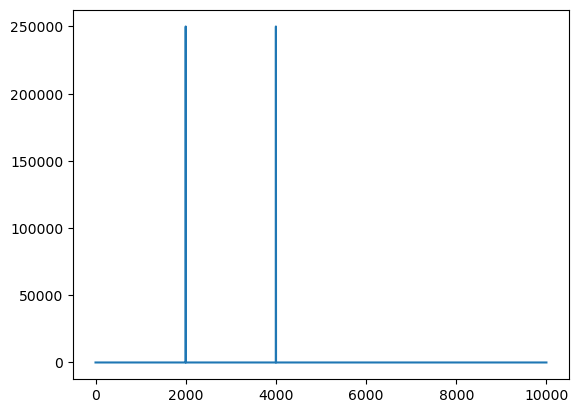

In [46]:
plt.figure()
plt.plot(freq_pf[:10000], Ampl_pf[:10000])
plt.show()

# Hightpass

In [159]:
cutoff = 6000

Wn = cutoff/(fs/2)

# Création du filtre
b, a = butter(N=8, Wn=Wn, btype='highpass')
w, h = signal.freqs(b ,a)
# Application du filtre
signal_filtered = filtfilt(b, a, signal_1_2_3)

In [160]:
b.shape, a.shape, signal_filtered.shape, Wn

((9,), (9,), (1000000,), 0.012)

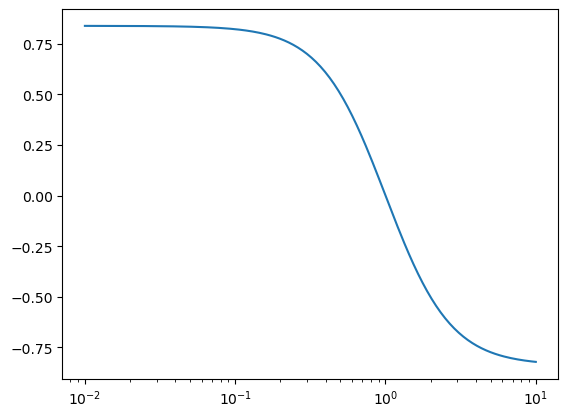

In [161]:
plt.figure()
# plt.plot(w, 20*np.log10(np.abs(h)))
plt.semilogx(w, 20 * np.log10(abs(h)))
plt.show()

In [ ]:
plt.figure()
plt.plot()
plt.title("Signal_filtred 100kHz + 1KHz")
plt.xlabel("Amplitude V")
plt.ylabel("Time s")
plt.show()

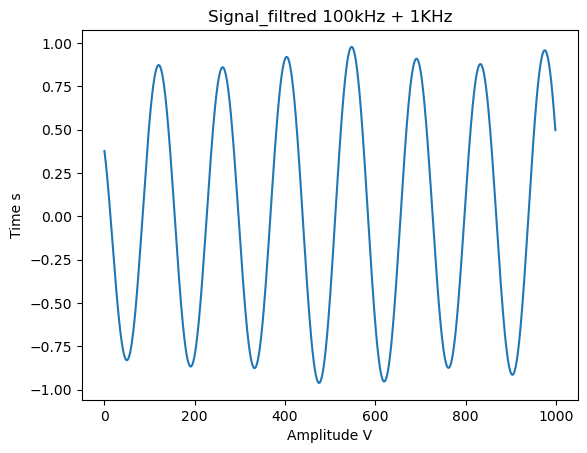

In [150]:
X = np.fft.fft(signal_filtered)

freqs = np.fft.fftfreq(N, d=1/fs)

Ampl = np.abs(X)

plt.figure()
plt.plot(signal_filtered[0:1000])
plt.title("Signal_filtred 100kHz + 1KHz")
plt.xlabel("Amplitude V")
plt.ylabel("Time s")
plt.show()

# bandpass

In [140]:
f_low = 3000
f_high = 6000

Wn = [f_low/(fs/2), f_high/(fs/2)]

# Création du filtre
b, a = butter(N=4, Wn=Wn, btype='bandpass')
w, h = signal.freqs(b ,a)
# Application du filtre
signal_filtered = filtfilt(b, a, signal_1_2_3)

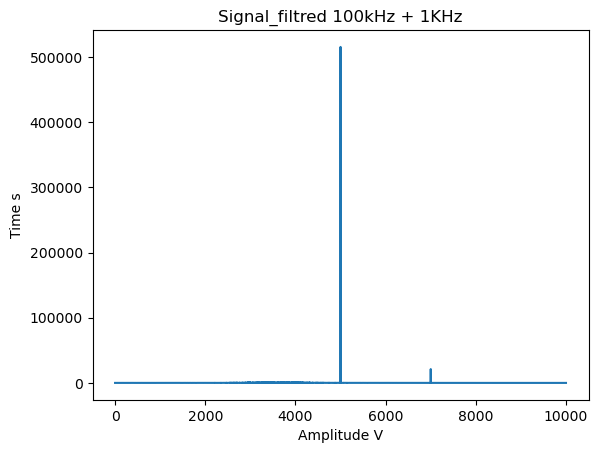

In [141]:
X = np.fft.fft(signal_filtered)

freqs = np.fft.fftfreq(N, d=1/fs)

Ampl = np.abs(X)

plt.figure()
plt.plot(freqs[0:10000], Ampl[0:10000])
plt.title("Signal_filtred 100kHz + 1KHz")
plt.xlabel("Amplitude V")
plt.ylabel("Time s")
plt.show()

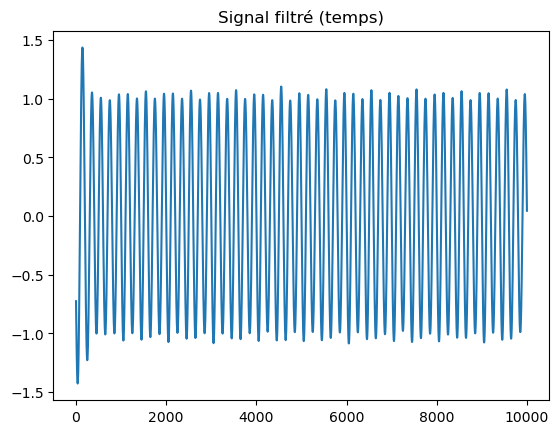

In [144]:
plt.plot(signal_filtered[:10000])
plt.title("Signal filtré (temps)")
plt.show()

# Part 2

In [10]:
import numpy as np
import matplotlib.pyplot as plt

In [24]:
fs = 32e6              # fréquence d'échantillonnage (1 MHz)
t = np.arange(0, 0.01, 1/fs)  # 10 ms

f_signal = 105e6      # signal à 100 kHz

# signal complexe (IQ)
samples = np.exp(1j * 2 * np.pi * f_signal * t)

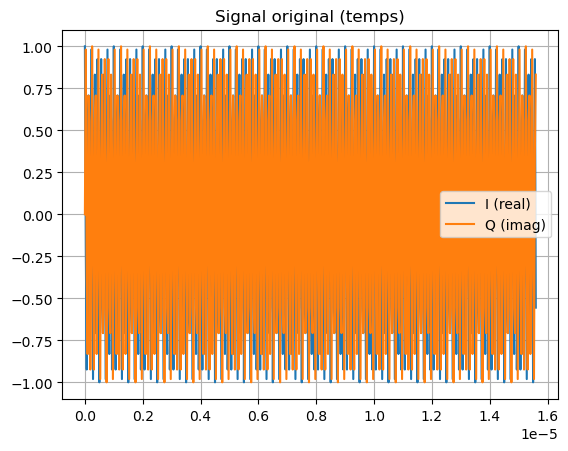

In [25]:
plt.figure()
plt.plot(t[:500], np.real(samples[:500]), label="I (real)")
plt.plot(t[:500], np.imag(samples[:500]), label="Q (imag)")
plt.title("Signal original (temps)")
plt.legend()
plt.grid()
plt.show()

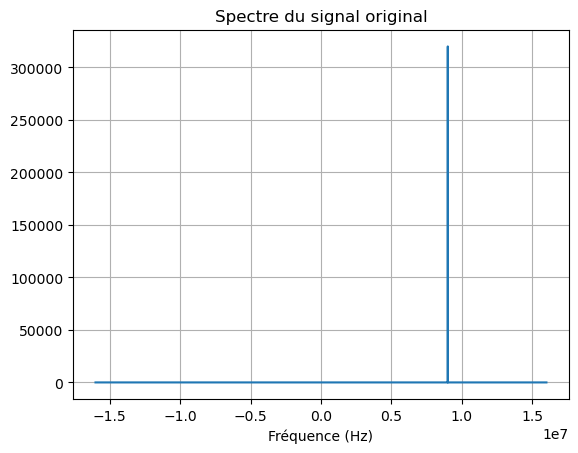

In [26]:
def plot_fft(signal, fs, title):
    N = len(signal)
    freq = np.fft.fftfreq(N, 1/fs)
    spectrum = np.fft.fft(signal)
    
    plt.figure()
    plt.plot(np.fft.fftshift(freq), np.fft.fftshift(np.abs(spectrum)))
    plt.title(title)
    plt.xlabel("Fréquence (Hz)")
    plt.grid()
    plt.show()

plot_fft(samples, fs, "Spectre du signal original")

In [54]:
f_offset = 1e6

samples_dc = samples * np.exp(-1j * 2 * np.pi * f_offset * t)

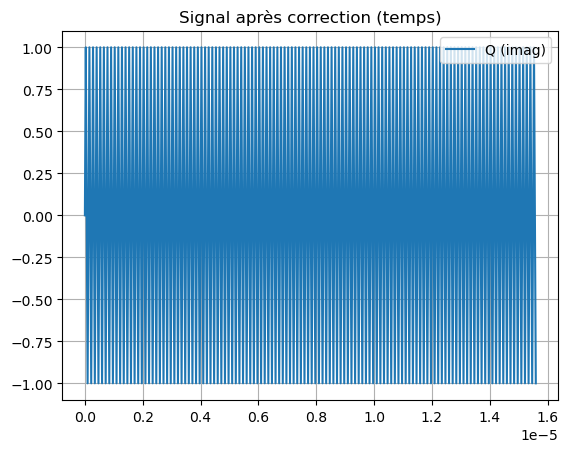

In [55]:
plt.figure()
# plt.plot(t[:], np.real(samples_dc[:]), label="I (real)")
plt.plot(t[:500], np.imag(samples_dc[:500]), label="Q (imag)")
plt.title("Signal après correction (temps)")
plt.legend()
plt.grid()
plt.show()

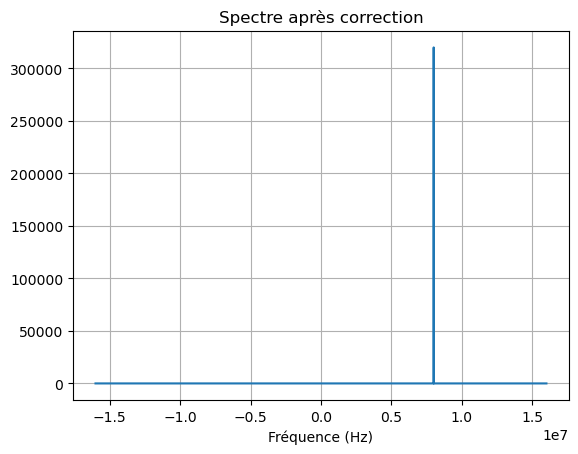

In [56]:
plot_fft(samples_dc, fs, "Spectre après correction")

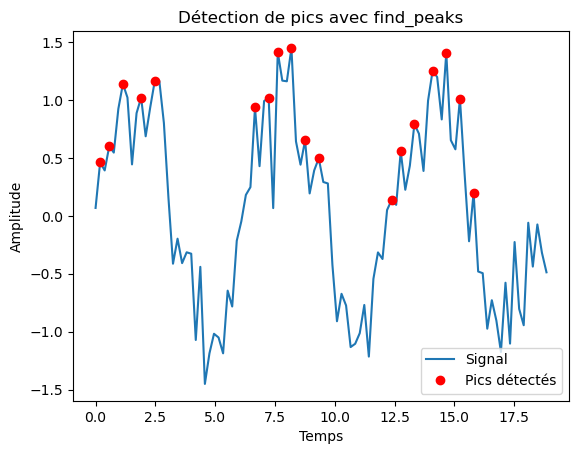

Indices des pics : [ 1  3  6 10 13 35 38 40 43 46 49 65 67 70 74 77 80 83]
Hauteur des pics : [0.46133492 0.60027552 1.13902438 1.02055888 1.16531414 0.93592737
 1.01808668 1.41305371 1.44969905 0.65246904 0.49669219 0.13680504
 0.55739257 0.79244339 1.25306653 1.40841078 1.01276827 0.19957915]


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# 1. Créer un signal (sinus + bruit)
x = np.linspace(0, 6*np.pi, 100)
signal = np.sin(x) + 0.3 * np.random.randn(100)

# 2. Détecter les pics
peaks, properties = find_peaks(signal, height=0)

# 3. Affichage
plt.figure()
plt.plot(x, signal, label="Signal")
plt.plot(x[peaks], signal[peaks], "ro", label="Pics détectés")
plt.legend()
plt.title("Détection de pics avec find_peaks")
plt.xlabel("Temps")
plt.ylabel("Amplitude")
plt.show()

# 4. Afficher les indices des pics
print("Indices des pics :", peaks)
print("Hauteur des pics :", properties["peak_heights"])

In [2]:
len(peaks)

18

In [4]:
import uhd

usrp = uhd.usrp.MultiUSRP()

print("GPIO banks:", usrp.get_gpio_banks(0))

GPIO banks: ['FP0', 'RXA', 'TXA']


In [2]:
import uhd
import time

usrp = uhd.usrp.MultiUSRP()

bank = "FP0"

# Mettre bits 8 et 9 en entrée
usrp.set_gpio_attr(bank, "DDR", 0x000, 0x300)

# for i in range(0, 5):
while True:
    value = usrp.get_gpio_attr(bank, "READBACK")
    gpio8 = (value >> 8) & 1
    gpio9 = (value >> 9) & 1

    print("GPIO8 =", gpio8, "GPIO9 =", gpio9)
    time.sleep(0.1)

GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1


[INFO] [B200] Loading firmware image: /usr/share/uhd/images/usrp_b200_fw.hex...
[INFO] [B200] Detected Device: B200
[INFO] [B200] Loading FPGA image: /usr/share/uhd/images/usrp_b200_fpga.bin...
[INFO] [B200] Operating over USB 3.
[INFO] [B200] Detecting internal GPSDO.... 
[INFO] [GPS] No GPSDO found
[INFO] [B200] Initialize CODEC control...
[INFO] [B200] Initialize Radio control...
[INFO] [B200] Performing register loopback test... 
[INFO] [B200] Register loopback test passed
[INFO] [B200] Setting master clock rate selection to 'automatic'.
[INFO] [B200] Asking for clock rate 16.000000 MHz... 
[INFO] [B200] Actually got clock rate 16.000000 MHz.


GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1
GPIO8 = 1 GPIO9 = 1


RuntimeError: AssertionError: accum_timeout < _timeout
  in wait_for_ack
  at ./host/lib/usrp/b200/b200_radio_ctrl_core.cpp:227


[ERROR] [UHD] An unexpected exception was caught in a task loop.The task loop will now exit, things may not work.EnvironmentError: IOError: usb rx8 transfer status: LIBUSB_TRANSFER_NO_DEVICE


In [9]:
import uhd
import time

usrp = uhd.usrp.MultiUSRP()
bank = "FP0"

MASK = 0x300  # GPIO8 + GPIO9

usrp.set_gpio_attr(bank, "DDR", MASK, MASK)

while True:
    usrp.set_gpio_attr(bank, "OUT", MASK, MASK)
    print("OUT HIGH =", hex(usrp.get_gpio_attr(bank, "OUT")))
    time.sleep(5)

    usrp.set_gpio_attr(bank, "OUT", 0x000, MASK)
    print("OUT LOW  =", hex(usrp.get_gpio_attr(bank, "OUT")))
    time.sleep(5)

OUT HIGH = 0x300
OUT LOW  = 0x0
OUT HIGH = 0x300
OUT LOW  = 0x0
OUT HIGH = 0x300
OUT LOW  = 0x0
OUT HIGH = 0x300
OUT LOW  = 0x0
OUT HIGH = 0x300
OUT LOW  = 0x0
OUT HIGH = 0x300
OUT LOW  = 0x0
OUT HIGH = 0x300
OUT LOW  = 0x0
OUT HIGH = 0x300


KeyboardInterrupt: 

[ERROR] [UHD] An unexpected exception was caught in a task loop.The task loop will now exit, things may not work.EnvironmentError: IOError: usb rx8 transfer status: LIBUSB_TRANSFER_NO_DEVICE


In [10]:
import uhd

usrp = uhd.usrp.MultiUSRP()

print("RX channels:", usrp.get_rx_num_channels())

RX channels: 1


In [3]:
import uhd

usrp = uhd.usrp.MultiUSRP()

print("RX channels:", usrp.get_rx_num_channels())
print("TX channels:", usrp.get_tx_num_channels())

print("RX0 antennas:", usrp.get_rx_antennas(0))
print("RX1 antennas:", usrp.get_rx_antennas(1))

RX channels: 2
TX channels: 2
RX0 antennas: ['TX/RX', 'RX2']
RX1 antennas: ['TX/RX', 'RX2']


[INFO] [B200] Detected Device: B210
[INFO] [B200] Operating over USB 3.
[INFO] [B200] Initialize CODEC control...
[INFO] [B200] Initialize Radio control...
[INFO] [B200] Performing register loopback test... 
[INFO] [B200] Register loopback test passed
[INFO] [B200] Performing register loopback test... 
[INFO] [B200] Register loopback test passed
[INFO] [B200] Setting master clock rate selection to 'automatic'.
[INFO] [B200] Asking for clock rate 16.000000 MHz... 
[INFO] [B200] Actually got clock rate 16.000000 MHz.


In [1]:
import uhd
import numpy as np

FREQ = 100e6
RATE = 1e6
GAIN = 30
NUM_SAMPS = 100000

usrp = uhd.usrp.MultiUSRP()

samples = usrp.recv_num_samps(
    NUM_SAMPS,
    FREQ,
    RATE,
    [0, 1],
    GAIN
)

print(samples.shape)

rx0 = samples[0]
rx1 = samples[1]

[INFO] [UHD] linux; GNU C++ version 13.2.0; Boost_108300; UHD_4.6.0.0+ds1-5.1ubuntu0.24.04.1
[INFO] [B200] Detected Device: B200
[INFO] [B200] Operating over USB 3.
[INFO] [B200] Initialize CODEC control...
[INFO] [B200] Initialize Radio control...
[INFO] [B200] Performing register loopback test... 
[INFO] [B200] Register loopback test passed
[INFO] [B200] Setting master clock rate selection to 'automatic'.
[INFO] [B200] Asking for clock rate 16.000000 MHz... 
[INFO] [B200] Actually got clock rate 16.000000 MHz.
[INFO] [B200] Asking for clock rate 32.000000 MHz... 
[INFO] [B200] Actually got clock rate 32.000000 MHz.


RuntimeError: LookupError: IndexError: multi_usrp: RX channel 1 out of range for configured RX frontends

In [5]:
import uhd

usrp = uhd.usrp.MultiUSRP()

print(usrp.get_gpio_banks(0))

['FP0', 'RXA', 'TXA']


In [6]:
import uhd
import time

usrp = uhd.usrp.MultiUSRP()

bank = "FP0"

MASK = 0x300   # GPIO8 + GPIO9
GPIO8 = 0x100
GPIO9 = 0x200

# config en sortie
usrp.set_gpio_attr(bank, "DDR", MASK, MASK)

while True:
    # GPIO8 HIGH
    usrp.set_gpio_attr(bank, "OUT", GPIO8, MASK)
    print("GPIO8 ON")
    time.sleep(3)

    # GPIO9 HIGH
    usrp.set_gpio_attr(bank, "OUT", GPIO9, MASK)
    print("GPIO9 ON")
    time.sleep(3)

    # OFF
    usrp.set_gpio_attr(bank, "OUT", 0x000, MASK)
    print("ALL OFF")
    time.sleep(3)

GPIO8 ON
GPIO9 ON
ALL OFF
GPIO8 ON
GPIO9 ON
ALL OFF
GPIO8 ON
GPIO9 ON
ALL OFF
GPIO8 ON
GPIO9 ON
ALL OFF
GPIO8 ON
GPIO9 ON
ALL OFF
GPIO8 ON
GPIO9 ON
ALL OFF
GPIO8 ON
GPIO9 ON
ALL OFF
GPIO8 ON
GPIO9 ON


KeyboardInterrupt: 

In [33]:
a = 0.0015
db = 20 * np.log10(a)
dbm = 10 * np.log10((a*a)/((1e-3)*50))
print(f"{a} V = {db} db = {dbm} dbm")

0.0015 V = -56.47817481888637 db = -43.46787486224656 dbm


In [34]:
a = 0.041
db = 20 * np.log10(a)
dbm = 10 * np.log10((a*a)/((1e-3)*50))
print(f"{a} V = {db} db = {dbm} dbm")

0.041 V = -27.74432286560529 db = -14.734022908965478 dbm


In [32]:
a = 0.01
db = 20 * np.log10(a)
dbm = 10 * np.log10((a*a)/((1e-3)*50))
print(f"{a} V = {db} db = {dbm} dbm")

0.01 V = -40.0 db = -26.989700043360187 dbm


In [2]:
dbm = -15   # exemple

v = np.sqrt(50 * 1e-3 * 10**(dbm / 10))

print(f"{dbm} dBm = {v} V RMS")

-15 dBm = 0.03976353643835254 V RMS


In [29]:
a = 35e-3
R = 50
P = (a*a)/R
dbm = 10 * np.log10((P)/(1e-3))

print(f"{a} V = {dbm} dbm")

0.035 V = -16.108339156354674 dbm


In [24]:
import numpy as np
import matplotlib.pyplot as plt
import uhd
from scipy.signal import get_window

# =======================
# CONFIGURATION
# =======================
FREQ = 100e6
GAIN = 50          # 80 est trop élevé pour B200, commence par 40-55
CHANNEL0 = 0
RATE = 10e6
NFFT = 4096
DURATION = 0.5

REMOVE_DC = True



# =======================
# ACQUISITION
# =======================
usrp = uhd.usrp.MultiUSRP()

num_samps = int(DURATION * RATE)

samples_2dim = usrp.recv_num_samps(
    num_samps,
    FREQ,
    RATE,
    [CHANNEL0],
    GAIN
)

if samples_2dim.ndim == 2:
    samples = samples_2dim[0]
else:
    samples = samples_2dim

print(f"Received {len(samples)} samples")

Received 5000000 samples


In [25]:
# =======================
# SPECTRE TYPE EXEMPLE FFT
# =======================
def compute_spectrum_like_example(samples, rate, freq_center, nfft=4096):
    samples = np.asarray(samples, dtype=np.complex64).ravel()

    if len(samples) < nfft:
        return np.array([]), np.array([])

    # enlever DC offset
    samples = samples - np.mean(samples)

    # prendre un seul bloc comme dans ton exemple
    x = samples[:nfft]

    # fenêtre pour réduire leakage
    window = np.blackman(nfft)
    x = x * window

    # FFT + fftshift
    X = np.fft.fft(x, n=nfft)
    X_shifted = np.fft.fftshift(X)

    # magnitude en dB
    X_mag_db = 10 * np.log10(np.abs(X_shifted) ** 2 + 1e-20)

    # axe fréquence
    f = np.fft.fftshift(np.fft.fftfreq(nfft, d=1 / rate)) + freq_center

    # supprimer le pic central restant
    center = nfft // 2
    X_mag_db[center - 5:center + 6] = np.nan

    return f, X_mag_db


def plot_spectrum(freqs, mag_db):
    plt.figure(figsize=(12, 5))
    plt.plot(freqs / 1e6, mag_db)

    # idx = np.nanargmax(mag_db)
    # plt.plot(freqs[idx] / 1e6, mag_db[idx], "rx")

    plt.title("Spectre FFT inspiré de l'exemple")
    plt.xlabel("Fréquence (MHz)")
    plt.ylabel("Magnitude [dB]")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

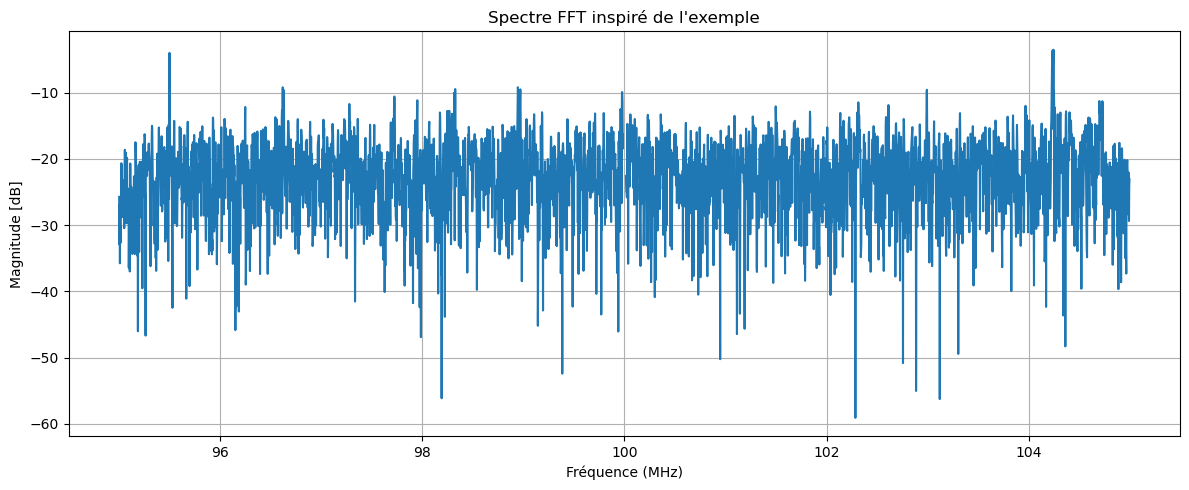

In [26]:
freqs, mag_db = compute_spectrum_like_example(
    samples,
    RATE,
    FREQ,
    nfft=NFFT
)

plot_spectrum(freqs, mag_db)

# From scratch

In [3]:
import numpy as np
a = 1
R = 50
P = (a*a)/R
dbm = 10 * np.log10((P)/(1e-3))

print(f"{a} V = {dbm} dbm")

1 V = 13.010299956639813 dbm


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import uhd
from scipy.signal import get_window

# =======================
# CONFIGURATION
# =======================
FREQ = 665e6
GAIN = 30          
CHANNEL0 = 0
RATE = 30e6
NFFT = 4096
DURATION = 1

REMOVE_DC = True



# =======================
# ACQUISITION
# =======================
usrp = uhd.usrp.MultiUSRP()

num_samps = int(DURATION * RATE)

samples_2dim = usrp.recv_num_samps(
    num_samps,
    FREQ,
    RATE,
    [CHANNEL0],
    GAIN
)

if samples_2dim.ndim == 2:
    samples = samples_2dim[0]
else:
    samples = samples_2dim

print(f"Received {len(samples)} samples")

[INFO] [UHD] linux; GNU C++ version 13.2.0; Boost_108300; UHD_4.6.0.0+ds1-5.1ubuntu0.24.04.1
[INFO] [B200] Detected Device: B210
[INFO] [B200] Operating over USB 3.
[INFO] [B200] Initialize CODEC control...
[INFO] [B200] Initialize Radio control...
[INFO] [B200] Performing register loopback test... 
[INFO] [B200] Register loopback test passed
[INFO] [B200] Performing register loopback test... 
[INFO] [B200] Register loopback test passed
[INFO] [B200] Setting master clock rate selection to 'automatic'.
[INFO] [B200] Asking for clock rate 16.000000 MHz... 
[INFO] [B200] Actually got clock rate 16.000000 MHz.
[INFO] [B200] Asking for clock rate 30.000000 MHz... 
[INFO] [B200] Actually got clock rate 30.000000 MHz.


Received 30000000 samples


In [4]:
import numpy as np

def compute_spectrum(samples, rate, freq_center, nfft=4096, remove_dc=True):

    samples = np.asarray(samples, dtype=np.complex64).ravel()

    if len(samples) < nfft:
        return np.array([]), np.array([])

    if remove_dc:
        samples = samples - np.mean(samples)

    n_blocks = len(samples) // nfft
    samples = samples[:n_blocks * nfft]

    blocks = samples.reshape(n_blocks, nfft)

    window = np.hanning(nfft)
    coherent_gain = np.sum(window) / nfft

    spec_acc = np.zeros(nfft)

    for blk in blocks:

        X = np.fft.fftshift(
            np.fft.fft(blk * window)
        )

        mag = np.abs(X) / (nfft * coherent_gain)

        spec_acc += mag

    mag_mean = spec_acc / n_blocks

    spectrum_dbfs = 20 * np.log10(
        np.maximum(mag_mean, 1e-15)
    )

    freqs = (
        np.fft.fftshift(
            np.fft.fftfreq(nfft, 1 / rate)
        )
        + freq_center
    )

    return freqs, spectrum_dbfs

def plot_spectrum(freqs, psd_db):
    plt.figure(figsize=(12, 5))
    plt.plot(freqs / 1e6, psd_db, linewidth=0.8)

    plt.title("Spectre PSD Welch")
    plt.xlabel("Fréquence (MHz)")
    plt.ylabel("Ampl DBFS")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

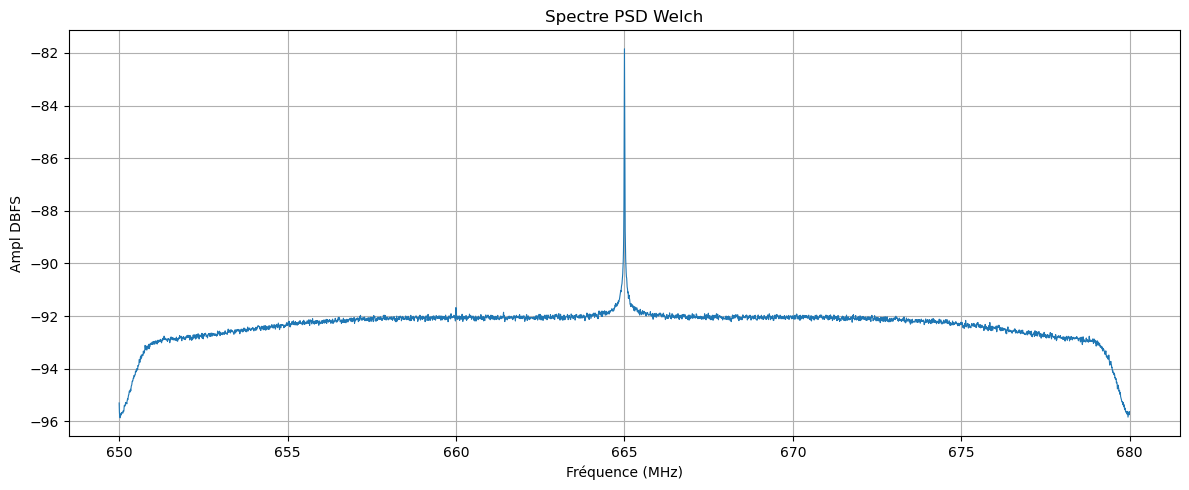

In [5]:
f, amp = compute_spectrum(samples, RATE, FREQ)

plot_spectrum(f, amp)

# Statistique test

## Spectre

In [2]:
import numpy as np
import matplotlib
# matplotlib.use("Agg")   # backend non interactif
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.signal import butter, filtfilt,freqs

import scipy.signal as signal

In [3]:
data_With = np.load("/home/yousef/Documents/testing_scripts/GEVernova/After_Aix/CAL2B_files/spectrum_With_DP.npz")
data_None = np.load("/home/yousef/Documents/testing_scripts/GEVernova/After_Aix/CAL2B_files/spectrum_None_DP.npz")

freqs_With = data_With["freqs"]
psd_With = data_With["psd"]

freqs_None = data_None["freqs"]
psd_None = data_None["psd"]

print(freqs_With.shape, psd_With.shape)
print(freqs_None.shape, psd_None.shape)

(22937,) (22937,)
(22937,) (22937,)


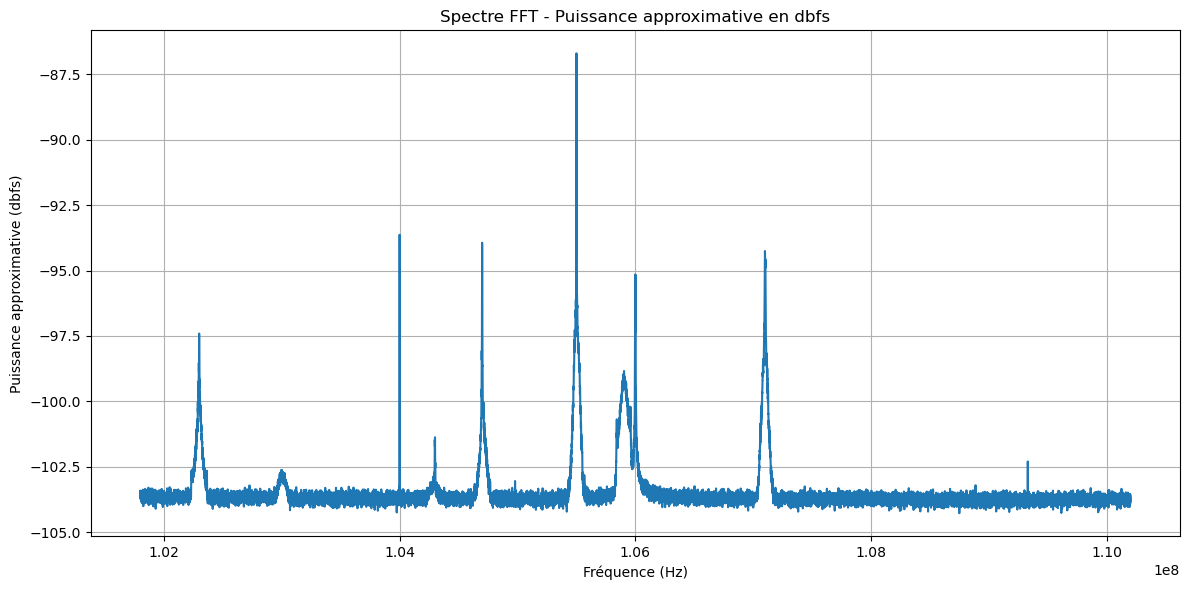

In [4]:
plt.figure(figsize=(12,6))
# plt.plot(freqs_With, psd_With)
plt.plot(freqs_None, psd_None)
plt.title(f"Spectre FFT - Puissance approximative en dbfs")
plt.xlabel("Fréquence (Hz)")
plt.ylabel(f"Puissance approximative (dbfs)")
plt.grid(True)

plt.tight_layout()
plt.show()

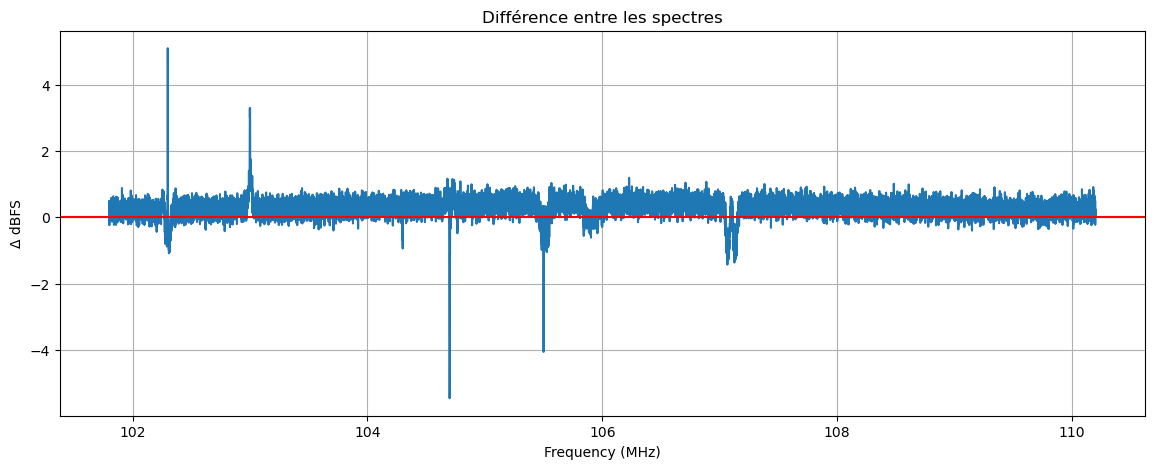

In [5]:
delta = psd_With - psd_None

plt.figure(figsize=(14,5))
plt.plot(freqs_With/1e6, delta)

plt.axhline(0,color='r')

plt.xlabel("Frequency (MHz)")
plt.ylabel("Δ dBFS")
plt.title("Différence entre les spectres")

plt.grid(True)
plt.show()

In [6]:
import numpy as np

distance = np.linalg.norm(
    psd_With - psd_None
)

print("Distance =", distance)

Distance = 61.18872763594951


In [7]:
corr = np.corrcoef(
    psd_With,
    psd_None
)[0,1]

print("Correlation =", corr)

Correlation = 0.9603590183821549


In [8]:
from scipy.stats import ks_2samp

stat, p = ks_2samp(
    psd_With,
    psd_None
)

print("KS statistic =", stat)
print("p-value =", p)

KS statistic = 0.6225312813358329
p-value = 0.0


In [9]:
delta = psd_With - psd_None

mu = np.mean(delta)
sigma = np.std(delta)

z = (delta - mu)/sigma

print("Max z-score =", np.max(np.abs(z)))

Max z-score = 20.302648247628394


Nombre de pics : 5


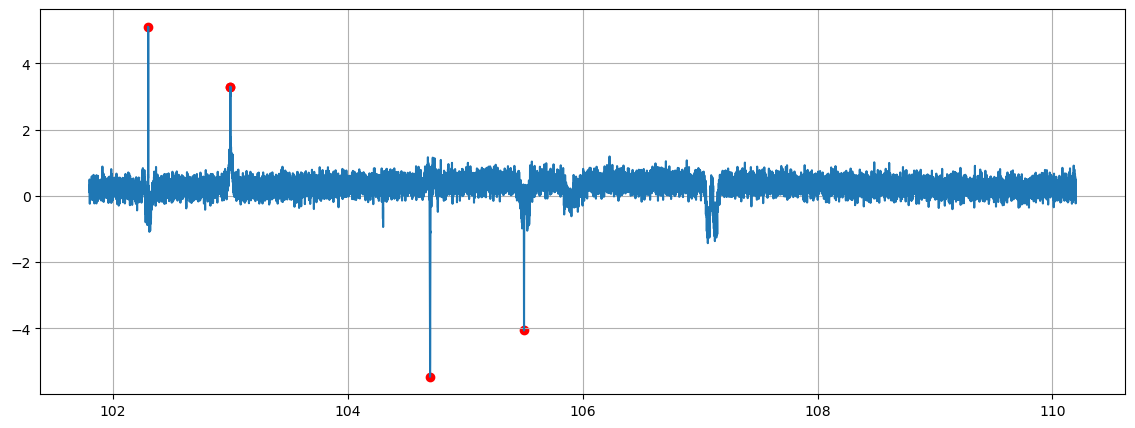

In [10]:
from scipy.signal import find_peaks

delta = psd_With - psd_None

peaks, props = find_peaks(
    np.abs(delta),
    height=3
)

print("Nombre de pics :", len(peaks))

plt.figure(figsize=(14,5))
plt.plot(freqs_With/1e6, delta)

plt.scatter(
    freqs_With[peaks]/1e6,
    delta[peaks],
    color='red'
)

plt.grid(True)
plt.show()

In [11]:
E_none = np.sum(10**(psd_None/10))
E_with = np.sum(10**(psd_With/10))

gain_db = 10*np.log10(E_with/E_none)

print("Gain énergétique =", gain_db, "dB")

Gain énergétique = 0.24541524813153384 dB


Nb bins anormaux : 198


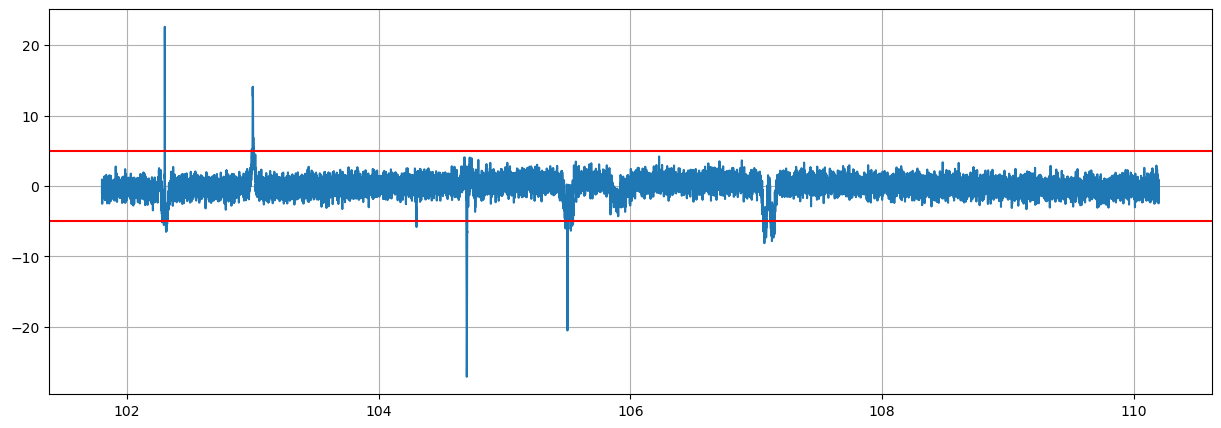

In [12]:
import numpy as np

delta = psd_With - psd_None

mu = np.median(delta)
sigma = 1.4826 * np.median(np.abs(delta - mu))

z = (delta - mu) / sigma

mask = np.abs(z) > 5

print("Nb bins anormaux :", np.sum(mask))
plt.figure(figsize=(15,5))

plt.plot(freqs_With/1e6, z)

plt.axhline(5,color='r')
plt.axhline(-5,color='r')

plt.grid()
plt.show()

In [13]:
n_anomalies = np.sum(np.abs(z) > 5)

ratio = n_anomalies / len(z)

print(ratio)

0.008632340759471595


## IQ

In [14]:
from scipy.stats import kurtosis

In [15]:
data_With = np.load("/home/yousef/Documents/testing_scripts/GEVernova/After_Aix/CAL2B_files/Time_With_DP.npz")
data_None = np.load("/home/yousef/Documents/testing_scripts/GEVernova/After_Aix/CAL2B_files/Time_None_DP.npz")

ampl_With = data_With["ampl"]


ampl_None = data_None["ampl"]

print(ampl_With.shape)
print(ampl_None.shape)

(36000000,)
(36000000,)


In [16]:
x_with = np.asarray(ampl_With, dtype=np.complex64).ravel()
x_none = np.asarray(ampl_None, dtype=np.complex64).ravel()

In [17]:
env_with = np.abs(x_with)
env_none = np.abs(x_none)

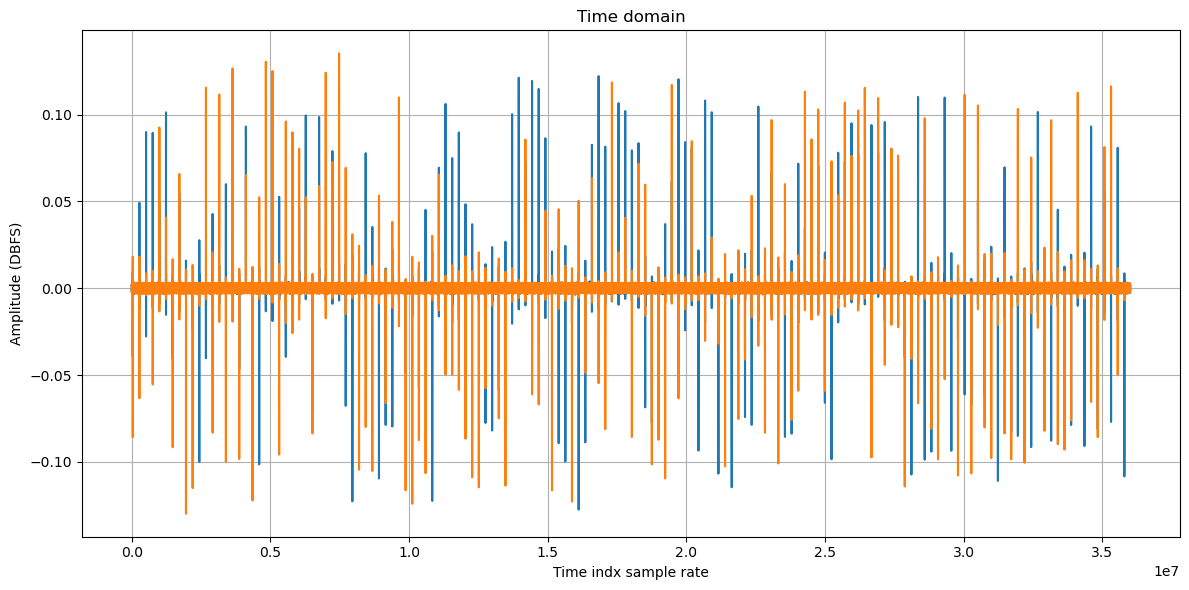

In [18]:
plt.figure(figsize=(12,6))
plt.plot(ampl_With.real)
plt.plot(ampl_With.imag)
plt.title(f"Time domain")
plt.xlabel("Time indx sample rate")
plt.ylabel(f"Amplitude (DBFS)")
plt.grid(True)

plt.tight_layout()
plt.show()

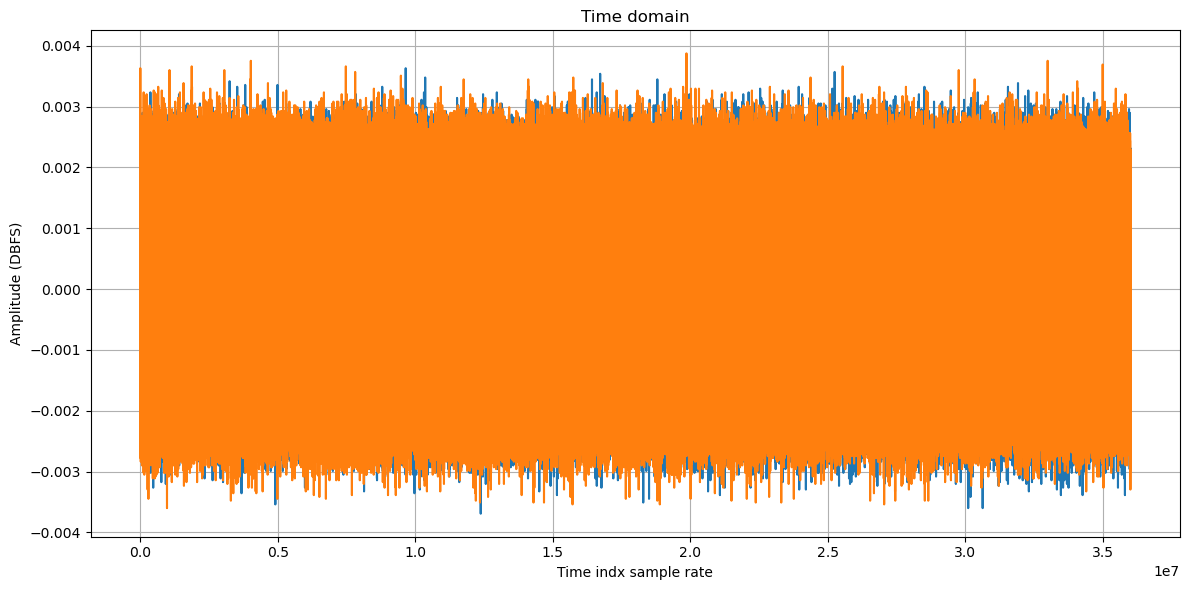

In [19]:
plt.figure(figsize=(12,6))
plt.plot(ampl_None.real)
plt.plot(ampl_None.imag)
plt.title(f"Time domain")
plt.xlabel("Time indx sample rate")
plt.ylabel(f"Amplitude (DBFS)")
plt.grid(True)

plt.tight_layout()
plt.show()

In [20]:
import numpy as np
from scipy.signal import find_peaks

FS = 12e6

x_with = np.asarray(ampl_With, dtype=np.complex64).ravel()
x_none = np.asarray(ampl_None, dtype=np.complex64).ravel()

env_with = np.abs(x_with)
env_none = np.abs(x_none)

mu = np.median(env_none)
sigma = 1.4826 * np.median(np.abs(env_none - mu))

threshold = mu + 6 * sigma

peaks_none, _ = find_peaks(env_none, height=threshold, distance=int(20e-6 * FS))
peaks_with, _ = find_peaks(env_with, height=threshold, distance=int(20e-6 * FS))

print("Pics sans DP :", len(peaks_none))
print("Pics avec DP :", len(peaks_with))
print("Ratio :", len(peaks_with) / max(len(peaks_none), 1))

Pics sans DP : 51
Pics avec DP : 360
Ratio : 7.0588235294117645


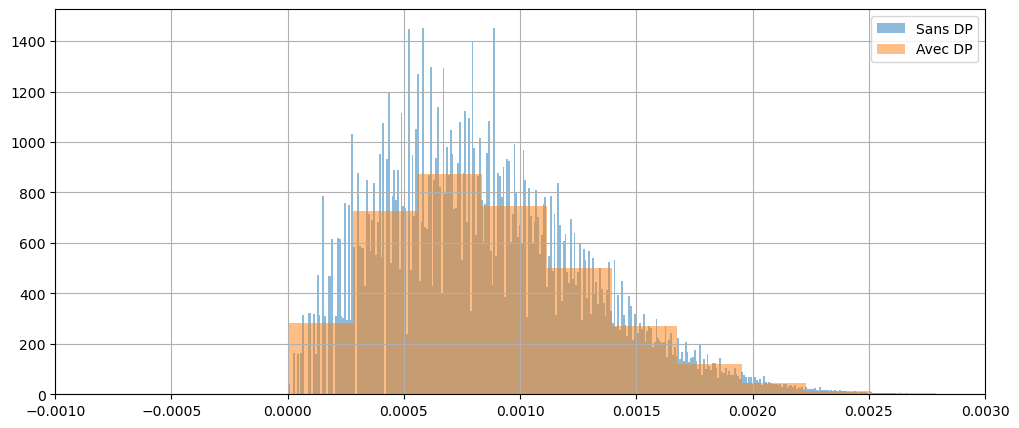

In [21]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.hist(
    env_none,
    bins=500,
    density=True,
    alpha=0.5,
    label="Sans DP"
)

plt.hist(
    env_with,
    bins=500,
    density=True,
    alpha=0.5,
    label="Avec DP"
)
plt.xlim(-0.001, 0.003)
plt.legend()
plt.grid()
plt.show()

In [22]:
from scipy.stats import ks_2samp

stat, p = ks_2samp(
    env_with,
    env_none
)

print("KS statistic =", stat)
print("p-value =", p)

KS statistic = 0.00032055555555554616
p-value = 0.04947475143379099


In [23]:
mu_noise = np.median(env_none)
mad_noise = np.median(np.abs(env_none - mu_noise))
sigma_noise = 1.4826 * mad_noise

K = 8  # seuil strict
threshold = mu_noise + K * sigma_noise

print("Noise median =", mu_noise)
print("Robust sigma =", sigma_noise)
print("Threshold =", threshold)

Noise median = 0.00080571155
Robust sigma = 0.000457984581857454
Threshold = 0.004469588203169405


In [24]:
min_distance_us = 20
min_distance = int(min_distance_us * 1e-6 * FS)

peaks_none, props_none = find_peaks(
    env_none,
    height=threshold,
    distance=min_distance
)

peaks_with, props_with = find_peaks(
    env_with,
    height=threshold,
    distance=min_distance
)

print("Pics sans DP :", len(peaks_none))
print("Pics avec DP :", len(peaks_with))

ratio_peaks = len(peaks_with) / max(len(peaks_none), 1)
print("Ratio pics avec/sans =", ratio_peaks)

Pics sans DP : 0
Pics avec DP : 298
Ratio pics avec/sans = 298.0


In [25]:
E_none = np.sum(env_none[peaks_none] ** 2)
E_with = np.sum(env_with[peaks_with] ** 2)

E_ratio_db = 10 * np.log10((E_with + 1e-20) / (E_none + 1e-20))

print("Énergie impulsionnelle sans DP =", E_none)
print("Énergie impulsionnelle avec DP =", E_with)
print("Gain énergie impulsionnelle =", E_ratio_db, "dB")

Énergie impulsionnelle sans DP = 0.0
Énergie impulsionnelle avec DP = 1.8849936
Gain énergie impulsionnelle = 202.75309869220263 dB


In [26]:
cf_none = np.max(env_none) / np.sqrt(np.mean(env_none**2))
cf_with = np.max(env_with) / np.sqrt(np.mean(env_with**2))

cf_none_db = 20*np.log10(cf_none)
cf_with_db = 20*np.log10(cf_with)

print("Crest factor sans DP =", cf_none_db, "dB")
print("Crest factor avec DP =", cf_with_db, "dB")
print("Différence CF =", cf_with_db - cf_none_db, "dB")

Crest factor sans DP = 12.123252153396606 dB
Crest factor avec DP = 42.85995006561279 dB
Différence CF = 30.736697912216187 dB


In [27]:
k_none = kurtosis(env_none, fisher=True)
k_with = kurtosis(env_with, fisher=True)

print("Kurtosis sans DP =", k_none)
print("Kurtosis avec DP =", k_with)
print("Différence kurtosis =", k_with - k_none)

Kurtosis sans DP = 0.2517083328849825
Kurtosis avec DP = 10077.063334482697
Différence kurtosis = 10076.81162614981


In [28]:
score = 0

if ratio_peaks > 2:
    score += 35
if E_ratio_db > 3:
    score += 30
if cf_with_db - cf_none_db > 3:
    score += 20
if k_with > k_none * 1.5:
    score += 15

score = min(score, 100)

print("Score présence DP =", score, "%")

if score >= 70:
    print("Conclusion : DP probable")
elif score >= 40:
    print("Conclusion : doute / changement possible")
else:
    print("Conclusion : pas de preuve forte de DP")

Score présence DP = 100 %
Conclusion : DP probable


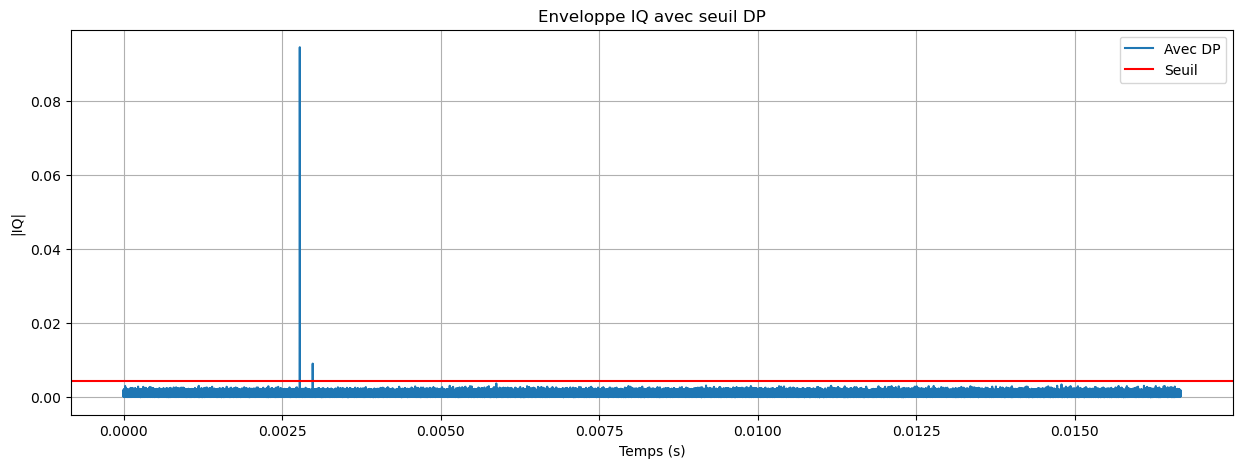

In [29]:
t = np.arange(len(env_with)) / FS

plt.figure(figsize=(15,5))
plt.plot(t[:200000], env_with[:200000], label="Avec DP")
plt.axhline(threshold, color="r", label="Seuil")
plt.xlabel("Temps (s)")
plt.ylabel("|IQ|")
plt.title("Enveloppe IQ avec seuil DP")
plt.grid()
plt.legend()
plt.show()

In [52]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# LOAD TIME SIGNALS
# =========================
data_With = np.load("/home/yousef/Documents/testing_scripts/GEVernova/After_Aix/CAL2B_files/Time_With_DP.npz")
data_None = np.load("/home/yousef/Documents/testing_scripts/GEVernova/After_Aix/CAL2B_files/Time_None_DP.npz")

ampl_With = data_With["ampl"]
ampl_None = data_None["ampl"]

print(ampl_With.shape)
print(ampl_None.shape)

# =========================
# PARAMETERS
# =========================
FS = 12e6        # sample rate
FC = 106e6       # fréquence centrale SDR si tu veux afficher en fréquence RF

# même longueur pour comparer proprement
N = min(len(ampl_With), len(ampl_None))
ampl_With = ampl_With[:N]
ampl_None = ampl_None[:N]

# # enlever DC
# ampl_With = ampl_With - np.mean(ampl_With)
# ampl_None = ampl_None - np.mean(ampl_None)

# =========================
# FFT SUR TOUS LES POINTS
# =========================
X_With = np.fft.fftshift(np.fft.fft(ampl_With))
X_None = np.fft.fftshift(np.fft.fft(ampl_None))

freqs_baseband = np.fft.fftshift(np.fft.fftfreq(N, d=1/FS))
freqs_rf = FC + freqs_baseband

# Magnitude en dB
mag_With_db = 20 * np.log10(np.maximum(np.abs(X_With) / N, 1e-15))
mag_None_db = 20 * np.log10(np.maximum(np.abs(X_None) / N, 1e-15))


(36000000,)
(36000000,)


shape =  (36000000,)


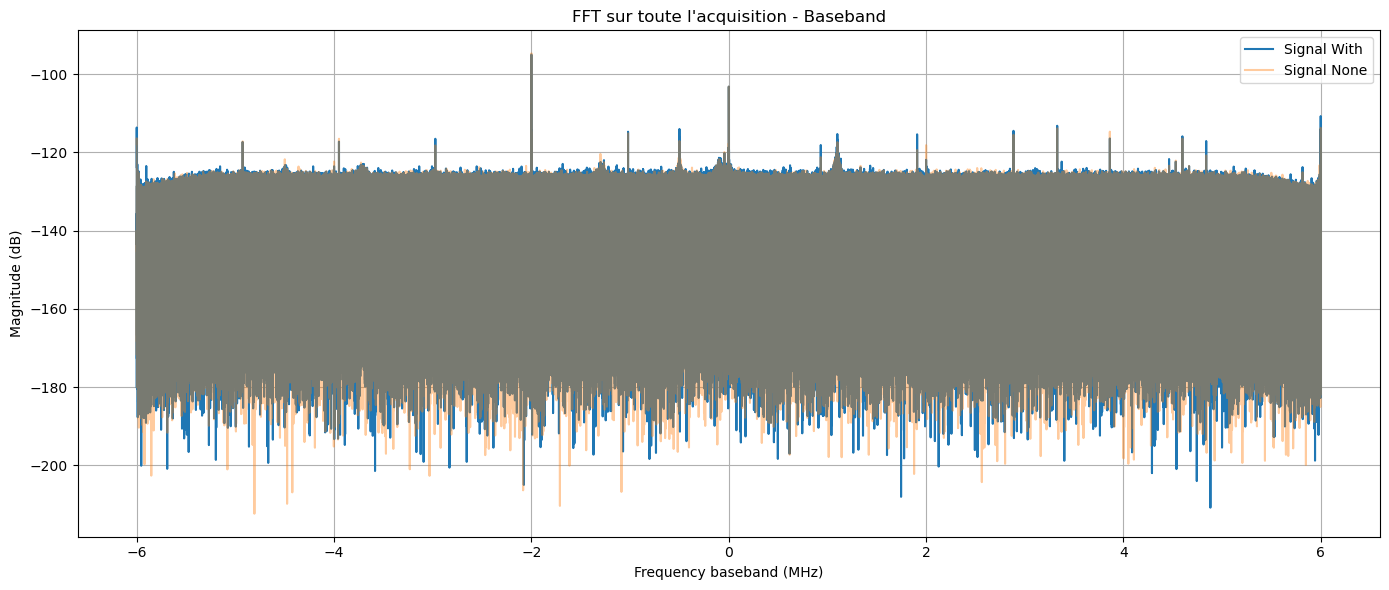

In [32]:
print("shape = ", X_With.shape)
# =========================
# PLOT BASEBAND
# =========================
plt.figure(figsize=(14, 6))
plt.plot(freqs_baseband / 1e6, mag_With_db, label="Signal With")
plt.plot(freqs_baseband / 1e6, mag_None_db, label="Signal None", alpha=0.4)
plt.xlabel("Frequency baseband (MHz)")
plt.ylabel("Magnitude (dB)")
plt.title("FFT sur toute l'acquisition - Baseband")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

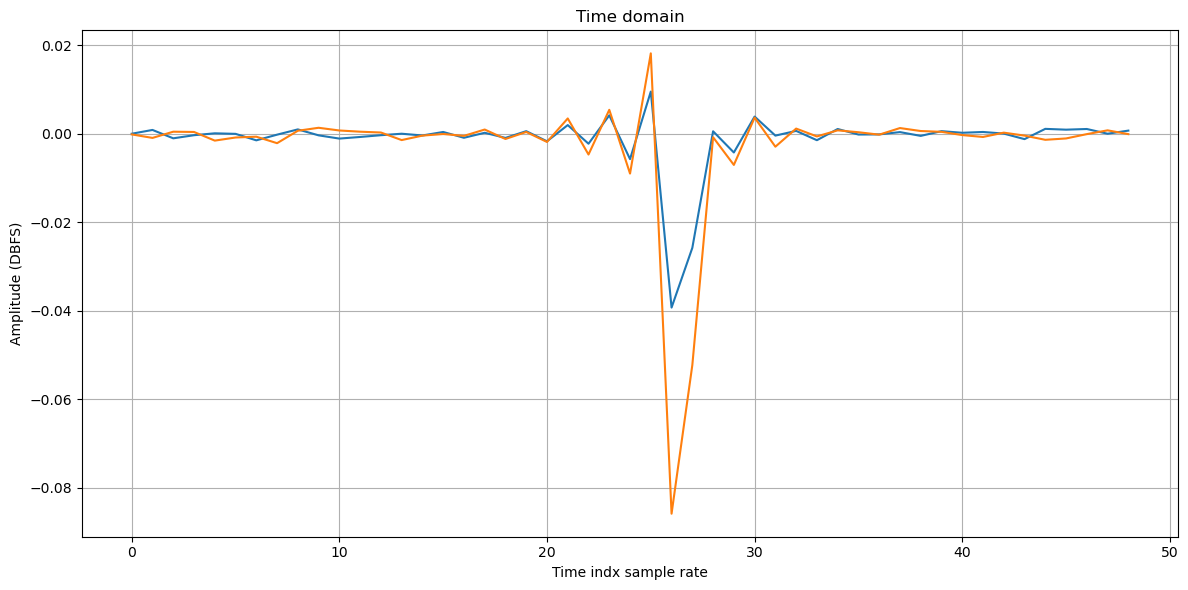

In [72]:
plt.figure(figsize=(12,6))
a = 32768*2
plt.plot(ampl_With.real[int(a/2)+int(a/120):int(a/2)+int(a/110)])
plt.plot(ampl_With.imag[int(a/2)+int(a/120):int(a/2)+int(a/110)])
plt.title(f"Time domain")
plt.xlabel("Time indx sample rate")
plt.ylabel(f"Amplitude (DBFS)")
plt.grid(True)

plt.tight_layout()
plt.show()

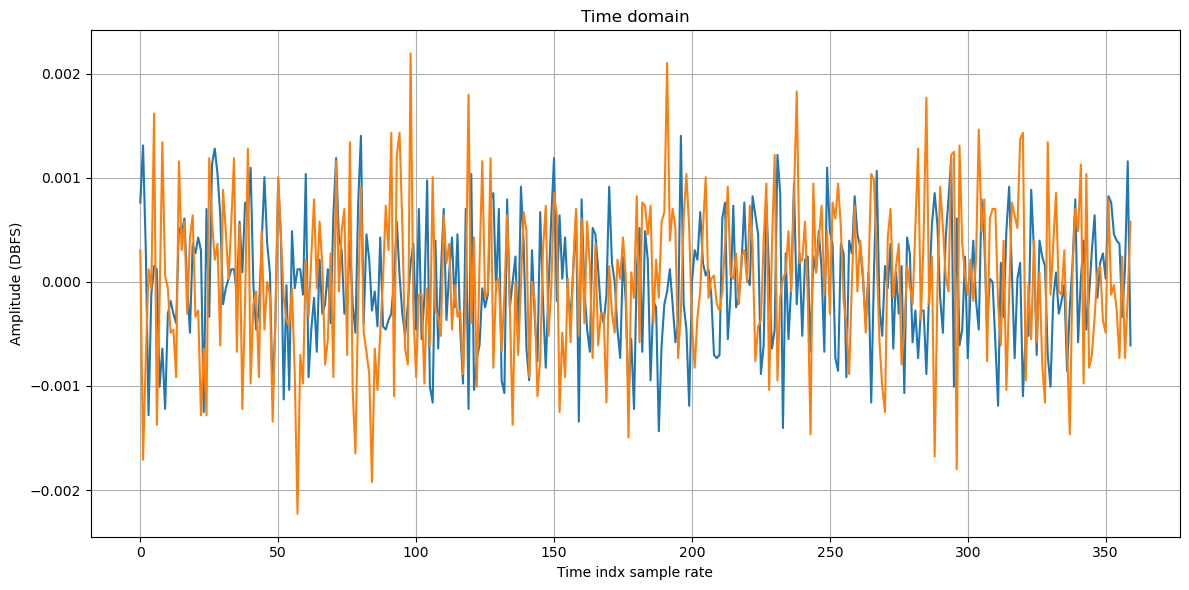

In [66]:
plt.figure(figsize=(12,6))
a = int(len(ampl_None)/100000)
plt.plot(ampl_None.real[:a])
plt.plot(ampl_None.imag[:a])
plt.title(f"Time domain")
plt.xlabel("Time indx sample rate")
plt.ylabel(f"Amplitude (DBFS)")
plt.grid(True)

plt.tight_layout()
plt.show()

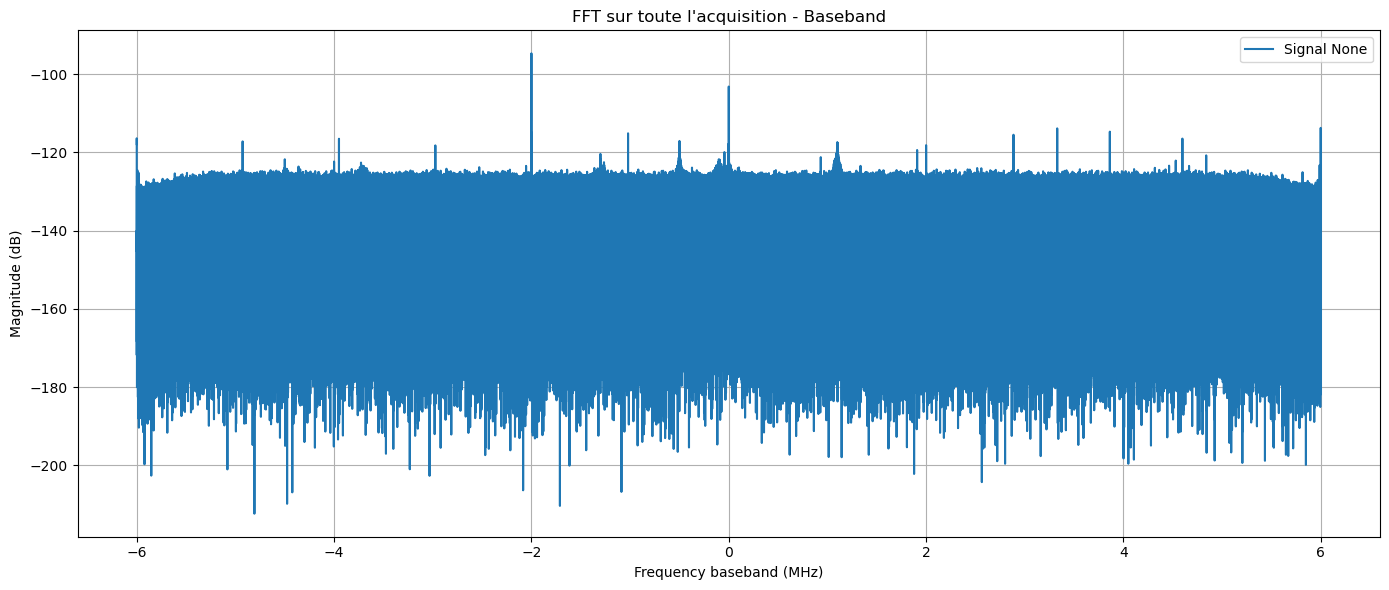

In [33]:
plt.figure(figsize=(14, 6))
# plt.plot(freqs_baseband / 1e6, mag_With_db, label="Signal With")
plt.plot(freqs_baseband / 1e6, mag_None_db, label="Signal None")
plt.xlabel("Frequency baseband (MHz)")
plt.ylabel("Magnitude (dB)")
plt.title("FFT sur toute l'acquisition - Baseband")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

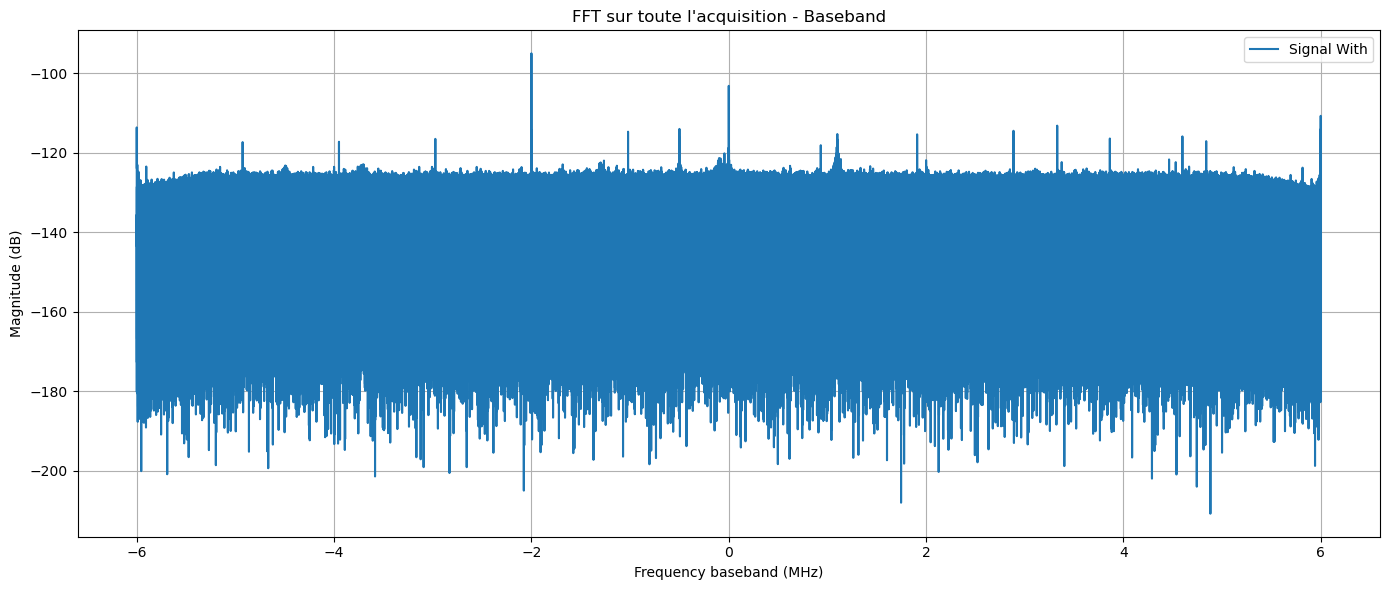

In [34]:
plt.figure(figsize=(14, 6))
plt.plot(freqs_baseband / 1e6, mag_With_db, label="Signal With")
# plt.plot(freqs_baseband / 1e6, mag_None_db, label="Signal None")
plt.xlabel("Frequency baseband (MHz)")
plt.ylabel("Magnitude (dB)")
plt.title("FFT sur toute l'acquisition - Baseband")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [73]:
def compute_spectrum_dbfs(
        samples,
        rate,
        freq_center,
        nfft=4096,
        remove_dc=True,
        edge_guard_hz=0.5e6
):
    samples = np.asarray(samples, dtype=np.complex64).ravel()

    if len(samples) < nfft:
        return np.array([]), np.array([])

    # =========================
    # SUPPRESSION DC
    # =========================
    if remove_dc:
        samples = samples - np.mean(samples)

    # =========================
    # BLOCS FFT
    # =========================
    n_blocks = len(samples) // nfft
    samples = samples[:n_blocks * nfft]

    blocks = samples.reshape(n_blocks, nfft)

    # =========================
    # FENÊTRE HANN
    # =========================
    window = np.hanning(nfft)

    # correction amplitude fenêtre
    coherent_gain = np.sum(window) / nfft

    # accumulation puissance
    p_acc = np.zeros(nfft)

    for blk in blocks:

        # fenêtre
        xw = blk * window

        # FFT
        X = np.fft.fftshift(np.fft.fft(xw, nfft))

        # normalisation FFT
        X = X / (nfft * coherent_gain)

        # puissance
        power = np.abs(X) ** 2

        # accumulation
        p_acc += power

    # moyenne
    p_mean = p_acc / n_blocks

    # =========================
    # NORMALISATION FULL SCALE
    # =========================

    # pleine échelle complexe normalisée
    full_scale_power = 1.0

    # conversion dBFS
    spectrum_dbfs = 10 * np.log10(
        np.clip(p_mean / full_scale_power, 1e-20, None)
    )

    # =========================
    # AXE FREQUENCES
    # =========================
    freqs = np.fft.fftshift(
        np.fft.fftfreq(nfft, d=1 / rate)
    ) + freq_center

    # =========================
    # SUPPRESSION EDGES
    # =========================
    half_bw = rate / 2

    mask_edges = (
        (freqs >= freq_center - half_bw + edge_guard_hz) &
        (freqs <= freq_center + half_bw - edge_guard_hz)
    )

    freqs = freqs[mask_edges]
    spectrum_dbfs = spectrum_dbfs[mask_edges]

    return freqs, spectrum_dbfs

shape =  (29,)


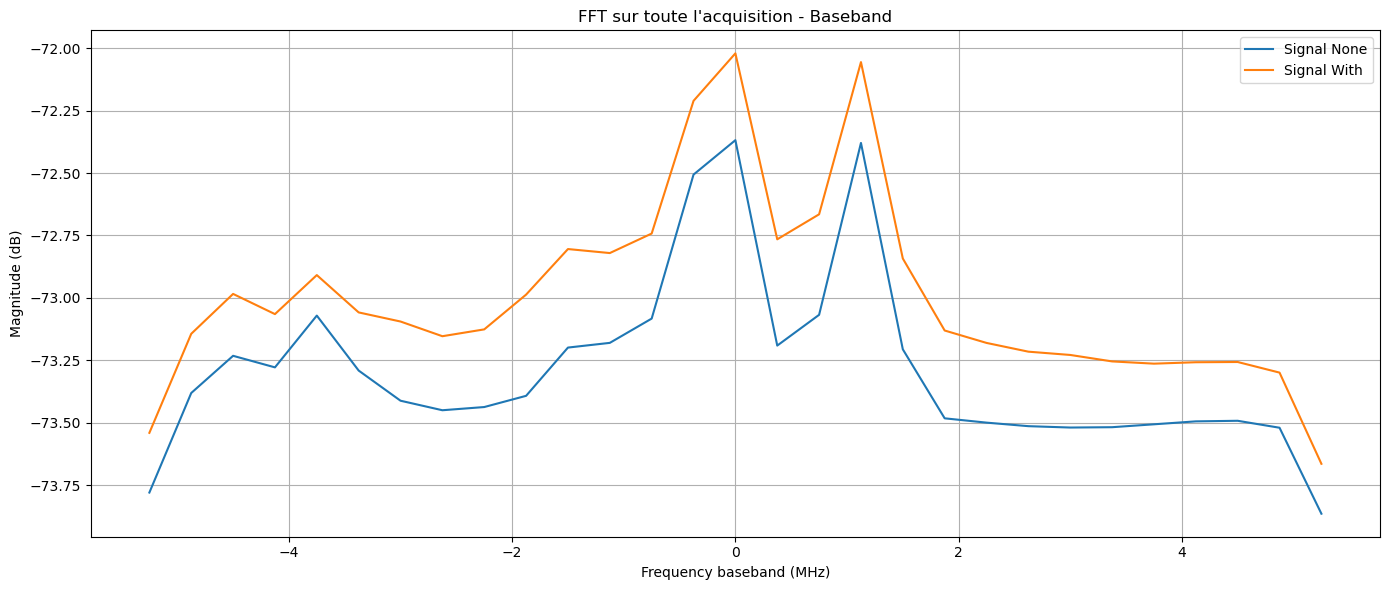

In [87]:
freqs, spectrum_None = compute_spectrum_dbfs(
        ampl_None,
        12e6,
        0,
        nfft=32,
        remove_dc=True,
        edge_guard_hz=0.5e6
)

freqs, spectrum_With = compute_spectrum_dbfs(
        ampl_With,
        12e6,
        0,
        nfft=32,
        remove_dc=True,
        edge_guard_hz=0.5e6
)
print("shape = ", spectrum_None.shape)
plt.figure(figsize=(14, 6))
plt.plot(freqs / 1e6, spectrum_None, label="Signal None")
plt.plot(freqs / 1e6, spectrum_With, label="Signal With")
plt.xlabel("Frequency baseband (MHz)")
plt.ylabel("Magnitude (dB)")
plt.title("FFT sur toute l'acquisition - Baseband")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

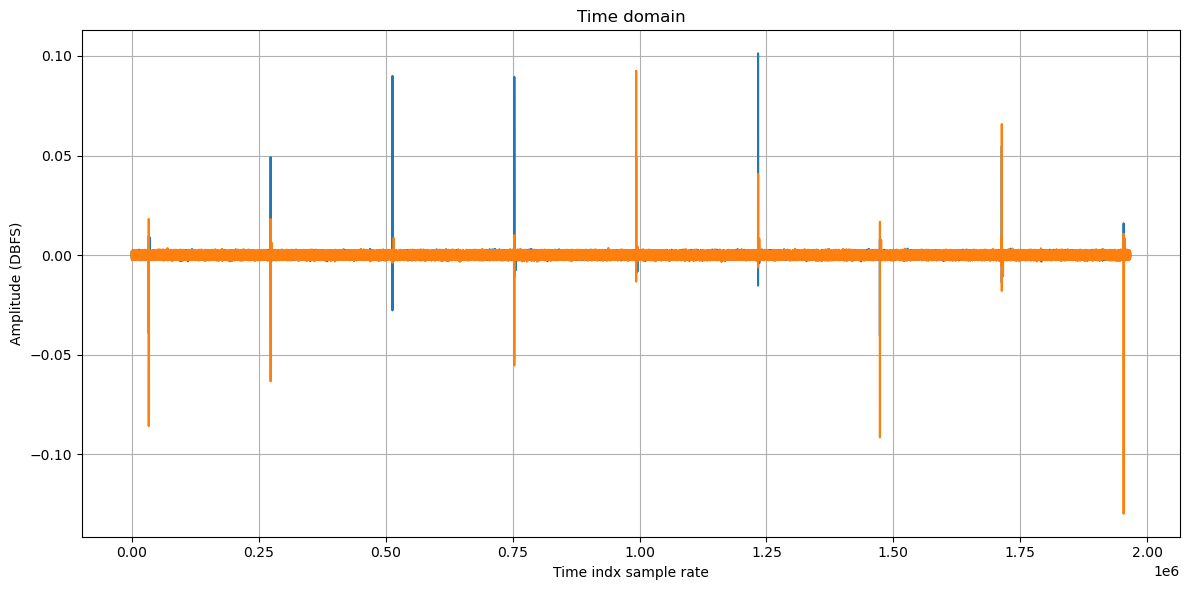

In [82]:
plt.figure(figsize=(12,6))
a = 32768*60
plt.plot(ampl_With.real[0:int(a)])
plt.plot(ampl_With.imag[0:int(a)])
plt.title(f"Time domain")
plt.xlabel("Time indx sample rate")
plt.ylabel(f"Amplitude (DBFS)")
plt.grid(True)

plt.tight_layout()
plt.show()

--- SIGNAL TEMPOREL ORIGINAL ---
[ 1.00000000e+00  7.07106781e-01  6.12323400e-17 -7.07106781e-01
 -1.00000000e+00 -7.07106781e-01 -1.83697020e-16  7.07106781e-01]

--------------------------------
--- NOTRE FFT (FROM SCRATCH) ---
Freq 0: (-0+0j)
Freq 1: (4-0j)
Freq 2: 0j
Freq 3: -0j
Freq 4: 0j
Freq 5: -0j
Freq 6: 0j
Freq 7: (4+0j)

--- FFT DE NUMPY (VÉRIFICATION) ---
Freq 0: (-0+0j)
Freq 1: (4-0j)
Freq 2: 0j
Freq 3: 0j
Freq 4: 0j
Freq 5: -0j
Freq 6: 0j
Freq 7: (4+0j)

✅ Succès ! Les résultats sont 100% identiques à Numpy !


/usr/lib/python3/dist-packages/matplotlib/cbook/__init__.py:1369: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


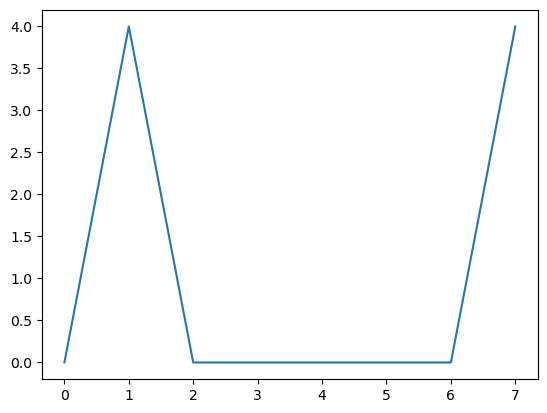

In [97]:
import cmath  # Module Python pour la manipulation des nombres complexes
import numpy as np


def fft_from_scratch(x):
    """Calcule la FFT 1D d'un signal x (dont la longueur doit être une puissance de 2)"""
    N = len(x)

    # --- Cas de base (Condition d'arrêt de la récursion) ---
    # La FFT d'un signal d'un seul point est le point lui-même.
    if N <= 1:
        return x

    # --- Étape 1 : Diviser ---
    # On sépare le signal en deux : les indices pairs et les indices impairs
    impair = fft_from_scratch(x[1::2])
    pair = fft_from_scratch(x[0::2])

    # --- Étape 2 : Régner et Recombiner ---
    # On prépare un tableau vide pour stocker le résultat de la FFT
    X = [0] * N

    # On combine les résultats des parties paires et impaires
    # Grâce aux propriétés de symétrie de la FFT, on ne fait la boucle que sur N/2
    for k in range(N // 2):
        # Calcul du facteur de rotation (Twiddle Factor) : e^(-2j * pi * k / N)
        facteur_rotation = cmath.exp(-2j * cmath.pi * k / N)

        # On applique le papillon de Cooley-Tukey (Butterfly combination)
        # Première moitié du spectre (de 0 à N/2)
        X[k] = pair[k] + facteur_rotation * impair[k]

        # Deuxième moitié du spectre (de N/2 à N) grâce à la périodicité
        X[k + N // 2] = pair[k] - facteur_rotation * impair[k]

    return X


# ==========================================
# TEST ET VÉRIFICATION DU CODE
# ==========================================

# 1. Création d'un signal de test simple (ex: 8 points pour que ce soit lisible)
# Un signal composé d'un cosinus
N_points = 8
t = np.linspace(0, 1, N_points, endpoint=False)
signal_test = np.cos(2 * np.pi * t)

print("--- SIGNAL TEMPOREL ORIGINAL ---")
print(signal_test)
print("\n--------------------------------")

# 2. Calcul avec notre fonction "from scratch"
spectre_custom = fft_from_scratch(signal_test)

# 3. Calcul avec la fonction officielle de Numpy (pour vérifier)
spectre_numpy = np.fft.fft(signal_test)

# 4. Affichage des résultats (on arrondit pour nettoyer l'affichage des micro-arrondis)
print("--- NOTRE FFT (FROM SCRATCH) ---")
for i, val in enumerate(spectre_custom):
    print(f"Freq {i}: {complex(round(val.real, 2), round(val.imag, 2))}")

print("\n--- FFT DE NUMPY (VÉRIFICATION) ---")
for i, val in enumerate(spectre_numpy):
    print(f"Freq {i}: {complex(round(val.real, 2), round(val.imag, 2))}")

# Vérification stricte
if np.allclose(spectre_custom, spectre_numpy):
    print("\n✅ Succès ! Les résultats sont 100% identiques à Numpy !")
else:
    print("\n❌ Il y a une différence dans les calculs.")

plt.figure()
plt.plot(spectre_custom)
plt.show()

In [118]:
def my_fft(x):
    N = len(x)
    n = np.arange(N)
    X = np.zeros(N, dtype=complex)
    for k in range(N):
        X[k]= np.sum(x * np.exp((-2j*np.pi*n*k)/N))
        

    return X

In [119]:
X = my_fft(signal_test)

In [120]:
X.shape

(8,)

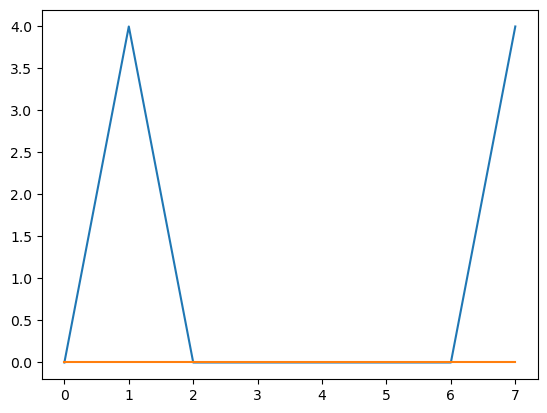

In [121]:
plt.figure()
plt.plot(X.real)
plt.plot(X.imag)
plt.show()

In [122]:
12e6*3

36000000.0

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram, find_peaks

# =========================
# 1. LOAD DATA
# =========================
data_With = np.load("/home/yousef/Documents/testing_scripts/GEVernova/After_Aix/CAL2B_files/Time_WithH_DP.npz")
data_None = np.load("/home/yousef/Documents/testing_scripts/GEVernova/After_Aix/CAL2B_files/Time_NoneH_DP.npz")

x_with = data_With["ampl"]
x_none = data_None["ampl"]

# =========================
# 2. PARAMETERS
# =========================
Fs = 12e6  # ADAPTER selon ton système



x_with_p = x_with.copy()
x_none_p = x_none.copy()

In [34]:
x_with.shape

(36000000,)

In [35]:
x_none.max(), x_with.max()

((0.064699225+0.008117922j), (0.10666216+0.0033570353j))

In [36]:
np.sqrt(x_none[:2400000].max().real**2 + x_none[:2400000].max().imag**2), np.sqrt(x_with[:2400000].max().real**2 + x_with[:2400000].max().imag**2)

(0.0602762662989871, 0.06720285158396214)

In [37]:
import numpy as np

def block_max_complex(x, block_size=2400000):
    results = []

    for i in range(0, len(x), block_size):
        block = x[i:i+block_size]

        if len(block) == 0:
            continue

        max_val = np.abs(block).max()
        results.append(max_val)

    return np.array(results)

res_none = block_max_complex(x_none, 2400000)
res_with = block_max_complex(x_with, 2400000)

print(res_none.mean(), res_with.mean())

0.06736973 0.10579943


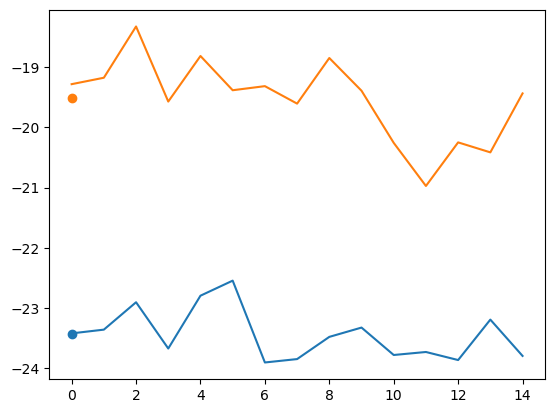

In [38]:
plt.figure()
plt.plot(20*np.log10(res_none+1e-20))
plt.plot(20*np.log10(res_with+1e-20))
plt.scatter(0, 20*np.log10(res_none.mean() + 1e-20))
plt.scatter(0, 20*np.log10(res_with.mean() + 1e-20))
plt.show()

In [46]:
20*np.log10(np.abs(x_with_p).sum() + 1e-20), 20*np.log10(np.abs(x_none_p).sum() + 1e-20), 20*np.log10(np.abs(np.abs(x_with_p).sum() - np.abs(x_none_p).sum()) + 1e-20)

(114.67063876466435, 114.77554875944409, 76.36319772794371)

In [47]:
np.abs(x_with_p).sum(), np.abs(x_none_p).sum()

(541417.06, 547996.06)

In [50]:
20*np.log10(np.abs(x_none_p).sum()) - 20*np.log10(np.abs(x_with_p).sum())

0.10491371154785156